In [1]:
import kagglehub
import shutil
from pathlib import Path

# Descargar dataset
download_path = kagglehub.dataset_download(
    "aasheesh200/framingham-heart-study-dataset"
)

print("Descargado en:", download_path)

# Crear carpeta data
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

# Buscar archivos csv descargados
for csv_file in Path(download_path).glob("*.csv"):
    destino = data_dir / csv_file.name
    shutil.copy(csv_file, destino)
    print(f"Copiado: {csv_file.name} -> {destino}")

Descargado en: C:\Users\Renato Villazon\.cache\kagglehub\datasets\aasheesh200\framingham-heart-study-dataset\versions\1
Copiado: framingham.csv -> ..\data\framingham.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

from statsmodels.stats.proportion import proportion_confint

sns.set_theme(style="whitegrid")

In [3]:
DATA_DIR = Path("../data")
CSV_FILE = DATA_DIR / "framingham.csv"

df = pd.read_csv(CSV_FILE)

print(df.shape)
df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
print("Filas y columnas:")
print(df.shape)

print("\nInformación general:")
print(df.info())

print("\nValores nulos:")
print(df.isnull().sum())

Filas y columnas:
(4240, 16)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64

In [5]:
df = df.dropna()

print(df.shape)

(3658, 16)


In [6]:
variables_numericas = [
    'age',
    'totChol',
    'sysBP',
    'diaBP',
    'BMI',
    'heartRate',
    'glucose'
]

df[variables_numericas].describe()

,age,totChol,sysBP,diaBP,BMI,heartRate,glucose
count,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000,3658.000000
mean,49.551941,236.847731,132.370558,82.917031,25.782802,75.730727,81.852925
std,8.562029,44.097681,22.086866,11.974258,4.065601,11.981525,23.904164
min,32.000000,113.000000,83.500000,48.000000,15.540000,44.000000,40.000000
25%,42.000000,206.000000,117.000000,75.000000,23.080000,68.000000,71.000000
50%,49.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000
75%,56.000000,263.000000,143.875000,90.000000,28.037500,82.000000,87.000000
max,70.000000,600.000000,295.000000,142.500000,56.800000,143.000000,394.000000


In [7]:
resumen = pd.DataFrame({
    "Media": df[variables_numericas].mean(),
    "Mediana": df[variables_numericas].median(),
    "Desv.Std": df[variables_numericas].std(),
    "Min": df[variables_numericas].min(),
    "Max": df[variables_numericas].max()
})

resumen

,Media,Mediana,Desv.Std,Min,Max
age,49.551941,49.00,8.562029,32.00,70.0
totChol,236.847731,234.00,44.097681,113.00,600.0
sysBP,132.370558,128.00,22.086866,83.50,295.0
diaBP,82.917031,82.00,11.974258,48.00,142.5
BMI,25.782802,25.38,4.065601,15.54,56.8
heartRate,75.730727,75.00,11.981525,44.00,143.0
glucose,81.852925,78.00,23.904164,40.00,394.0


In [8]:
variables_categoricas = [
    'male',
    'currentSmoker',
    'BPMeds',
    'diabetes',
    'TenYearCHD'
]

for col in variables_categoricas:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())
    print()
    print(round(df[col].value_counts(normalize=True)*100,2))


===== male =====
male
0    2035
1    1623
Name: count, dtype: int64

male
0    55.63
1    44.37
Name: proportion, dtype: float64

===== currentSmoker =====
currentSmoker
0    1869
1    1789
Name: count, dtype: int64

currentSmoker
0    51.09
1    48.91
Name: proportion, dtype: float64

===== BPMeds =====
BPMeds
0.0    3547
1.0     111
Name: count, dtype: int64

BPMeds
0.0    96.97
1.0     3.03
Name: proportion, dtype: float64

===== diabetes =====
diabetes
0    3559
1      99
Name: count, dtype: int64

diabetes
0    97.29
1     2.71
Name: proportion, dtype: float64

===== TenYearCHD =====
TenYearCHD
0    3101
1     557
Name: count, dtype: int64

TenYearCHD
0    84.77
1    15.23
Name: proportion, dtype: float64


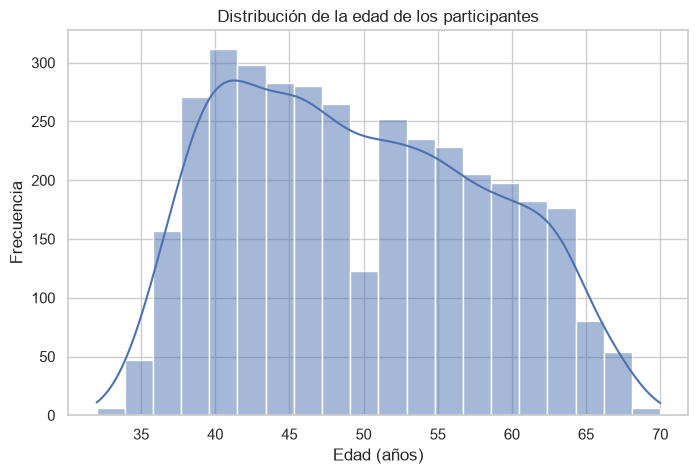

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Distribución de la edad de los participantes")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")

plt.show()

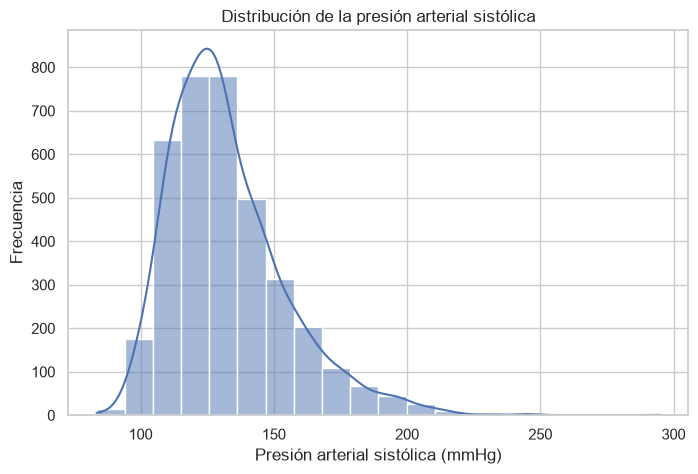

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['sysBP'], bins=20, kde=True)

plt.title("Distribución de la presión arterial sistólica")
plt.xlabel("Presión arterial sistólica (mmHg)")
plt.ylabel("Frecuencia")

plt.show()

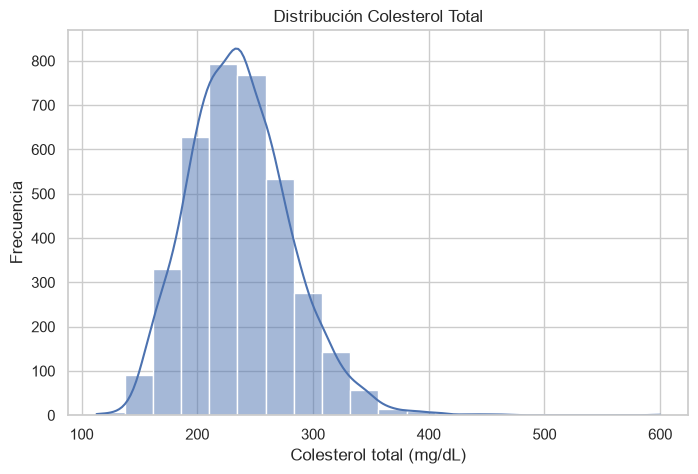

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['totChol'], bins=20, kde=True)

plt.title("Distribución Colesterol Total")
plt.xlabel("Colesterol total (mg/dL)")
plt.ylabel("Frecuencia")

plt.show()

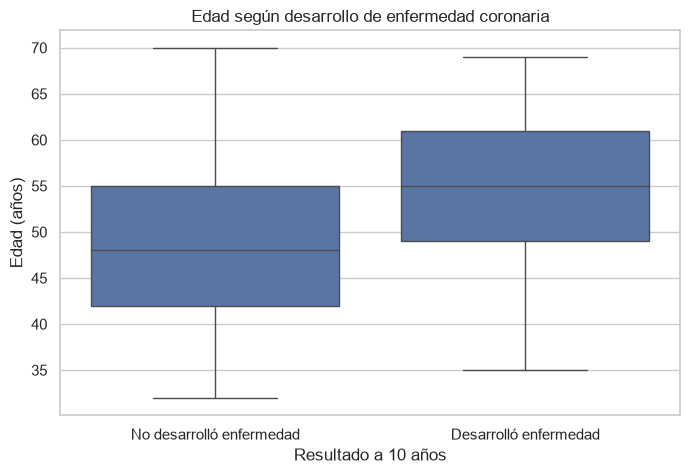

In [12]:
df["CHD_Label"] = df["TenYearCHD"].map({
    0: "No desarrolló enfermedad",
    1: "Desarrolló enfermedad"
})

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="CHD_Label",
    y="age"
)

plt.xlabel("Resultado a 10 años")
plt.ylabel("Edad (años)")
plt.title("Edad según desarrollo de enfermedad coronaria")

plt.show()

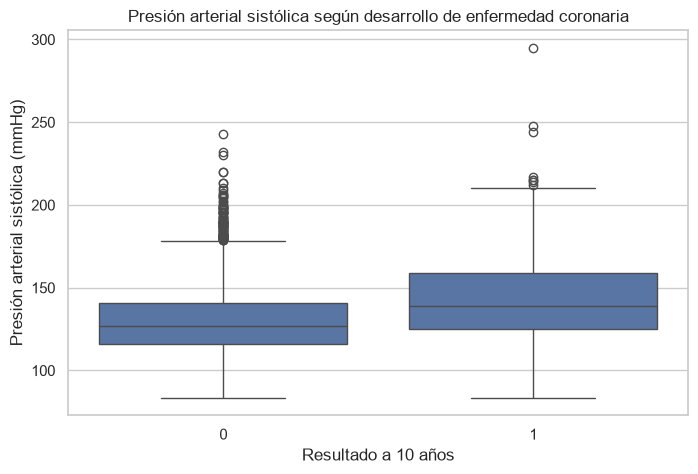

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='TenYearCHD',
    y='sysBP'
)

plt.title("Presión arterial sistólica según desarrollo de enfermedad coronaria")
plt.xlabel("Resultado a 10 años")
plt.ylabel("Presión arterial sistólica (mmHg)")

plt.show()

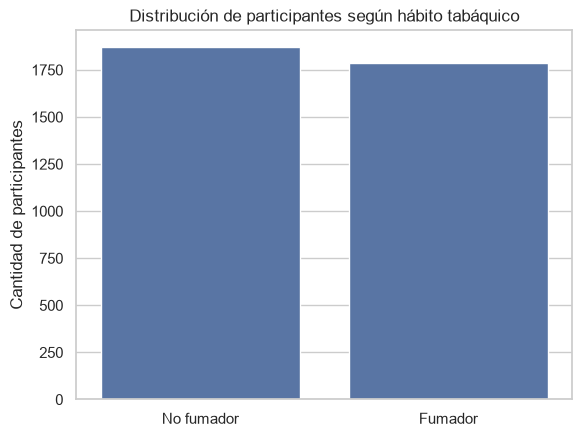

In [14]:
df["Smoker_Label"] = df["currentSmoker"].map({
    0: "No fumador",
    1: "Fumador"
})

sns.countplot(
    data=df,
    x="Smoker_Label"
)

plt.xlabel("")
plt.ylabel("Cantidad de participantes")
plt.title("Distribución de participantes según hábito tabáquico")

plt.show()

In [15]:
media_edad = df['age'].mean()

print("Edad promedio:")
print(round(media_edad,2))

Edad promedio:
49.55


In [16]:
confianza = 0.95

n = len(df)

media = df['age'].mean()

desv = stats.sem(df['age'])

ic = stats.t.interval(
    confianza,
    n-1,
    loc=media,
    scale=desv
)

print("IC 95% edad:")
print(ic)

IC 95% edad:
(np.float64(49.27438744301972), np.float64(49.829494459659344))


In [17]:
p = df['TenYearCHD'].mean()

print("Proporción:")
print(round(p,4))

Proporción:
0.1523


In [18]:
casos = df['TenYearCHD'].sum()

total = len(df)

ic_prop = proportion_confint(
    casos,
    total,
    alpha=0.05,
    method='wilson'
)

print("IC 95% proporción enfermedad coronaria")
print(ic_prop)

IC 95% proporción enfermedad coronaria
(0.1409912833530232, 0.1642762907326933)


In [19]:
grupo0 = df[df['TenYearCHD']==0]['age']

grupo1 = df[df['TenYearCHD']==1]['age']

t_stat, p_value = ttest_ind(
    grupo0,
    grupo1,
    equal_var=False
)

print("Estadístico t:")
print(t_stat)

print("p-value:")
print(p_value)

Estadístico t:
-15.043735216262723
p-value:
3.559858873342705e-45


In [20]:
alpha = 0.05

if p_value < alpha:
    print("Se rechaza H0")
    print("Existe diferencia significativa en la edad.")
else:
    print("No se rechaza H0")

Se rechaza H0
Existe diferencia significativa en la edad.


In [21]:
tabla = pd.crosstab(
    df['currentSmoker'],
    df['TenYearCHD']
)

tabla

TenYearCHD,0,1
currentSmoker,,
0,1597,272
1,1504,285


In [22]:
chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 1.2389725931725915
p-value: 0.2656691520743377


In [23]:
if p < 0.05:
    print("Existe asociación entre fumar y enfermedad coronaria.")
else:
    print("No existe evidencia suficiente de asociación.")

No existe evidencia suficiente de asociación.


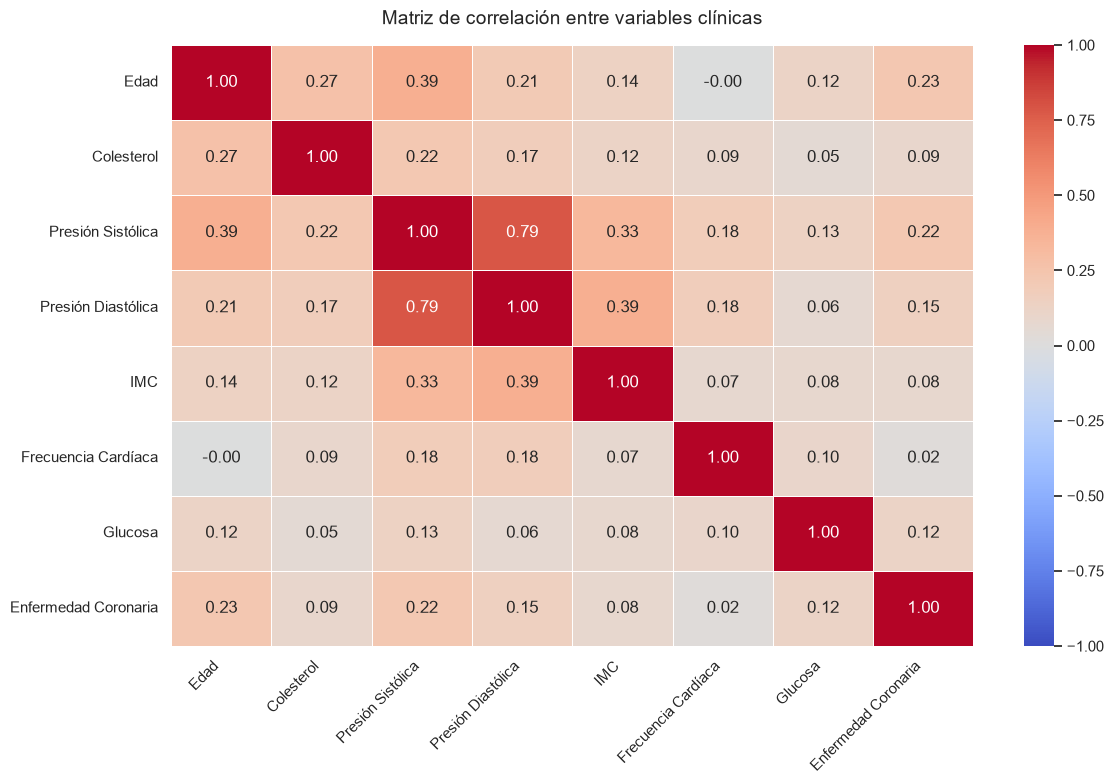

In [24]:
corr_df = df.rename(columns={
    "age": "Edad",
    "totChol": "Colesterol",
    "sysBP": "Presión Sistólica",
    "diaBP": "Presión Diastólica",
    "BMI": "IMC",
    "heartRate": "Frecuencia Cardíaca",
    "glucose": "Glucosa",
    "TenYearCHD": "Enfermedad Coronaria"
})

corr_variables = [
    "Edad",
    "Colesterol",
    "Presión Sistólica",
    "Presión Diastólica",
    "IMC",
    "Frecuencia Cardíaca",
    "Glucosa",
    "Enfermedad Coronaria"
]

corr_matrix = corr_df[corr_variables].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Matriz de correlación entre variables clínicas",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()